# Score One Recording By Chunks

Runs a single EDF straight through the same scoring pipeline as
`hypnose_somnotate.scoring.score_recordings` (used by
`scripts/sleep_scoring/score_recordings.py`), but stops to show every
intermediate `prepare_recording` scoring chunk on its own — its own
predicted states, state probabilities, and state fractions — alongside the
merged whole-recording output the pipeline normally writes.

**Why this exists:** `prepare_recording`
(`hypnose_somnotate.preprocessing.gap_correction`) decides, from the gaps it
finds in the recording, whether to score the whole kept range as *one* chunk
(`trim_only`/`mask_inline`) or split it into several independent chunks at
long gaps (`split`). Scoring normalizes each chunk's spectral-power features
by that chunk's own robust mean/std
(`hypnose_somnotate.somnotate_pipeline.preprocessing.preprocess_signals.preprocess`,
`robust_normalize(..., axis=1)`) — so a chunk spanning a very long or
gap-containing recording gets different normalization statistics than a
shorter one would, which can shift NREM/REM/Wake classification across the
*entire* chunk, not just near a gap. Comparing chunks side by side here is
how you spot that: e.g. one chunk scoring mostly NREM while the state
distribution of a neighbouring chunk looks implausibly different.

Use `notebook/view_scored_recording_direct_paths.ipynb` afterwards to view
the merged output (saved here in the same parquet format) against the raw
traces.

## 1. Imports

Install missing packages in the notebook environment if needed:

```bash
pip install mne pandas pyedflib six pomegranate scikit-learn
```


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "scripts").exists() and (REPO_ROOT.parent / "scripts").exists():
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from hypnose_somnotate.config import MODEL_TO_OUTPUT_LABEL
from hypnose_somnotate.somnotate._automated_state_annotation import StateAnnotator
from hypnose_somnotate.somnotate._utils import convert_state_vector_to_state_intervals
from hypnose_somnotate.somnotate_pipeline.io.data_io import load_raw_signals
from hypnose_somnotate.somnotate_pipeline.utils import configuration
from hypnose_somnotate.preprocessing.gap_correction import prepare_recording
from hypnose_somnotate.preprocessing.preprocessing import (
    compute_global_normalization_stats,
    preprocess_multichannel,
)

# Reused rather than reimplemented so this notebook can never drift from what
# `score_recordings` actually does for a given recording.
from hypnose_somnotate.scoring.scoring import (
    _predict_state_probabilities,
    _score_prepared_recording,
)


## 2. Settings

- `EDF_PATH`: the recording to score (a single-session EDF, or a
  `_recording-concat.edf` produced by `scripts/preprocessing/concatenate_recordings.py`).
- `MODEL_PATH`: a trained `model.pickle` (see `configs/pipelines/sleep_scoring.yaml`'s
  `sleep_scoring.model_path`, resolved under the derivatives root).
- `CHANNEL_LABELS`: EEG1, EEG2, EMG in that order. Either spelling works — with
  or without the repeated `EEG `/`EMG ` prefix — `load_raw_signals` resolves
  against whichever the EDF actually has.
- `GLOBAL_NORMALIZATION`: `False` (default) reproduces today's production
  behaviour — each scoring chunk is normalized against its own
  percentile-trimmed mean/std. Set to `True` to instead normalize every
  chunk against one set of statistics pooled across *all* chunks (gap/
  too_short epochs excluded) — see section 4b and the `global_normalization`
  option added to `hypnose_somnotate.scoring.score_recordings` /
  `_score_prepared_recording`. Run this notebook once with each value to
  compare their effect on the same recording (section 6 and the diagnostic
  in section 9 make the comparison concrete).
- `OUTPUT_DIR`: set to a folder to save the merged predictions parquet +
  segments JSON (same filenames `score_recordings` would use, plus a
  `_normlocal`/`_normglobal` suffix so both variants can be saved side by
  side without overwriting each other). Leave `None` to only keep results in
  memory.


In [2]:
EDF_PATH = Path("/mnt/harris/hypnose/hypnose_eeg/rawdata/sub-063_id-430/ses-001_date-20260715/ephys/sub-063_ses-001_recording-concat.edf")
MODEL_PATH = Path("/mnt/harris/hypnose/hypnose_eeg/derivatives/somnotate_training/somno_model_1/model.pickle")
CHANNEL_LABELS = ["EEG1A-B", "EEG2A-B", "EMG"]
SAMPLING_RATE_HZ = 512
GLOBAL_NORMALIZATION = True  # set True to normalize every chunk against pooled, recording-wide stats
OUTPUT_DIR = "/mnt/harris/hypnose/hypnose_eeg/testing"  # e.g. Path("/path/to/scratch_output")

if not EDF_PATH.is_file():
    raise FileNotFoundError(f"EDF not found: {EDF_PATH}")
if not MODEL_PATH.is_file():
    raise FileNotFoundError(f"Model not found: {MODEL_PATH}")
if len(CHANNEL_LABELS) != 3:
    raise ValueError("CHANNEL_LABELS must contain exactly three labels: EEG1, EEG2, EMG")
if OUTPUT_DIR is not None:
    OUTPUT_DIR = Path(OUTPUT_DIR)
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## 3. Load Raw Signals & Model

`load_raw_signals` is the exact function `score_recordings` calls — it reads
EDF *digital* samples (not physical units) for the three configured channels.


In [3]:
raw_signals = load_raw_signals(str(EDF_PATH), CHANNEL_LABELS)
print(f"Loaded {raw_signals.shape[0]:,} samples x {raw_signals.shape[1]} channels from {EDF_PATH.name}")

annotator = StateAnnotator()
annotator.load(str(MODEL_PATH))
print(f"Loaded model from {MODEL_PATH}")


Loaded 222,230,016 samples x 3 channels from sub-063_ses-001_recording-concat.edf
Loaded model from /mnt/harris/hypnose/hypnose_eeg/derivatives/somnotate_training/somno_model_1/model.pickle


## 4. Prepare the Recording (Gap Detection & Chunking Plan)

`prepare_recording` detects constant-value runs (missing/disconnected
signal), decides a strategy (`trim_only` / `mask_inline` / `split`), and
returns the `scoring_chunks` that will actually be fed to the model plus the
`segments` covering the entire original timeline (`signal` / `gap` /
`too_short`). See the module docstring in
`hypnose_somnotate/preprocessing/gap_correction.py` for the full strategy
rationale (`max_missing_fraction=0.05`, `max_single_gap_s=30 min`,
`min_segment_length_s=10 min`, all overridable here as keyword arguments if
you want to test different thresholds against this same recording).


In [4]:
prepared = prepare_recording(
    raw_signals,
    sampling_rate_hz=SAMPLING_RATE_HZ,
    time_resolution_s=configuration.time_resolution,
)

print(f"Strategy: {prepared.strategy}")
print(
    f"Duration: {prepared.original_duration_s / 3600:.2f} h | "
    f"missing: {prepared.total_missing_s:.0f} s "
    f"({100 * prepared.missing_fraction:.1f}%) | "
    f"longest gap: {prepared.longest_gap_s:.0f} s"
)
print(f"{len(prepared.scoring_chunks)} scoring chunk(s), {len(prepared.segments)} segment(s)")

segments_df = pd.DataFrame([s.to_dict() for s in prepared.segments])
segments_df


Strategy: split
Duration: 120.57 h | missing: 18710 s (4.3%) | longest gap: 11444 s
7 scoring chunk(s), 32 segment(s)


,segment_id,kind,original_start_s,original_end_s,duration_s
0,0,signal,0.0,10186.0,10186.0
1,1,gap,10186.0,10193.0,7.0
2,2,too_short,10193.0,10194.0,1.0
3,3,gap,10194.0,10201.0,7.0
4,4,too_short,10201.0,10203.0,2.0
5,5,gap,10203.0,10212.0,9.0
6,6,too_short,10212.0,10244.0,32.0
7,7,gap,10244.0,10247.0,3.0
8,8,too_short,10247.0,10281.0,34.0
9,9,gap,10281.0,10283.0,2.0


In [5]:
chunks_df = pd.DataFrame(
    {
        "chunk_id": range(len(prepared.scoring_chunks)),
        "start_s": [c.original_start_s for c in prepared.scoring_chunks],
        "end_s": [c.original_end_s for c in prepared.scoring_chunks],
        "duration_s": [c.original_end_s - c.original_start_s for c in prepared.scoring_chunks],
        "n_samples": [c.raw_signal.shape[0] for c in prepared.scoring_chunks],
    }
)
chunks_df


,chunk_id,start_s,end_s,duration_s,n_samples
0,0,0,10186,10186,5215232
1,1,10317,14493,4176,2138112
2,2,21459,25795,4336,2220032
3,3,25956,170869,144913,74195456
4,4,182313,316641,134328,68775936
5,5,316643,344107,27464,14061568
6,6,344109,434039,89930,46044160


## 4b. Global Normalization Statistics (optional)

`compute_global_normalization_stats` pools the (pre-normalization) log
spectrogram from every "signal" epoch across *all* `prepared.scoring_chunks`
— excluding "gap"/"too_short" epochs so zero-padding never contributes — and
returns one `(robust_mean, robust_std)` pair per channel. Passing this into
`preprocess_multichannel(..., normalization_stats=...)` normalizes every
chunk against that single, recording-wide baseline instead of each chunk's
own statistics.

This cell only computes the stats; whether they're actually *used* below is
controlled by `GLOBAL_NORMALIZATION` from section 2.


In [6]:
global_stats = compute_global_normalization_stats(prepared, SAMPLING_RATE_HZ)
normalization_stats = global_stats if GLOBAL_NORMALIZATION else None

print(f"GLOBAL_NORMALIZATION = {GLOBAL_NORMALIZATION}")
for ch_idx, stats in enumerate(global_stats):
    if stats is None:
        print(f"  channel {ch_idx}: no signal epochs found -- falls back to local per-chunk normalization")
    else:
        mean, std = stats
        print(
            f"  channel {ch_idx}: pooled robust mean/std over {len(mean)} frequency bins "
            f"(mean of means={np.mean(mean):.4g}, mean of stds={np.mean(std):.4g})"
        )


GLOBAL_NORMALIZATION = True
  channel 0: pooled robust mean/std over 78 frequency bins (mean of means=7.724, mean of stds=0.6038)
  channel 1: pooled robust mean/std over 78 frequency bins (mean of means=8.228, mean of stds=0.6373)
  channel 2: pooled robust mean/std over 78 frequency bins (mean of means=9.748, mean of stds=1.968)


## 5. Score Each Chunk Individually

For each `ScoringChunk`, this runs the same two calls `_score_prepared_recording`
makes internally (`preprocess_multichannel` then `annotator.predict` /
`_predict_state_probabilities`) but keeps every chunk's output separate,
instead of merging them into one recording-wide array. `label_model` follows
somnotate's own convention (1=awake, 2=non-REM, 3=REM, 0=undefined,
artefact sign already folded in via `abs`); `label_output` is the pipeline's
display convention (0=Wake, 1=NREM, 2=REM, 3=Undefined).


In [7]:
chunk_results: list[pd.DataFrame] = []

for chunk_id, chunk in enumerate(prepared.scoring_chunks):
    preprocessed = preprocess_multichannel(
        chunk.raw_signal, SAMPLING_RATE_HZ, normalization_stats=normalization_stats
    )
    label_model = np.abs(np.asarray(annotator.predict(preprocessed), dtype=int))
    probs = _predict_state_probabilities(annotator, preprocessed)

    n = len(label_model)
    time_s_in_chunk = np.arange(n, dtype=float) * configuration.time_resolution
    label_output = np.fromiter(
        (MODEL_TO_OUTPUT_LABEL.get(int(v), 3) for v in label_model),
        dtype=int,
        count=n,
    )

    chunk_df = pd.DataFrame(
        {
            "chunk_id": chunk_id,
            "time_s_in_chunk": time_s_in_chunk,
            "time_s_absolute": chunk.original_start_s + time_s_in_chunk,
            "label_model": label_model,
            "label_state": [configuration.int_to_state.get(v, "undefined") for v in label_model],
            "label_output": label_output,
            "prob_wake": np.clip(probs.get(1, np.zeros(n)), 0.0, 1.0),
            "prob_nrem": np.clip(probs.get(2, np.zeros(n)), 0.0, 1.0),
            "prob_rem": np.clip(probs.get(3, np.zeros(n)), 0.0, 1.0),
            "prob_undef": np.clip(probs.get(0, np.zeros(n)), 0.0, 1.0),
        }
    )
    chunk_results.append(chunk_df)

    print(
        f"chunk {chunk_id}: [{chunk.original_start_s:.0f}, {chunk.original_end_s:.0f}] s "
        f"({n} epochs) scored"
    )


chunk 0: [0, 10186] s (10186 epochs) scored
chunk 1: [10317, 14493] s (4176 epochs) scored
chunk 2: [21459, 25795] s (4336 epochs) scored
chunk 3: [25956, 170869] s (144913 epochs) scored
chunk 4: [182313, 316641] s (134328 epochs) scored
chunk 5: [316643, 344107] s (27464 epochs) scored
chunk 6: [344109, 434039] s (89930 epochs) scored


## 6. Compare State Distributions Across Chunks

The state fraction each chunk was assigned is the fastest way to spot a
chunk whose normalization statistics went wrong: a chunk with an implausibly
high or low NREM/REM fraction compared to its neighbours — especially in a
`mask_inline`-scored recording, where *every* chunk shares the same
recording-wide normalization — is exactly the symptom described in the
investigation this notebook was built to support.


In [8]:
state_fraction_rows = []
for chunk_id, chunk_df in enumerate(chunk_results):
    counts = chunk_df["label_state"].value_counts(normalize=True)
    row = {"chunk_id": chunk_id, "n_epochs": len(chunk_df)}
    row.update({state: counts.get(state, 0.0) for state in ("awake", "non-REM", "REM", "undefined")})
    state_fraction_rows.append(row)

state_fractions_df = pd.DataFrame(state_fraction_rows).set_index("chunk_id")
state_fractions_df


,n_epochs,awake,non-REM,REM,undefined
chunk_id,,,,,
0,10186,0.894168,0.105832,0.000000,0.0
1,4176,0.519875,0.443966,0.036159,0.0
2,4336,0.840175,0.159825,0.000000,0.0
3,144913,0.405084,0.512128,0.082788,0.0
4,134328,0.511531,0.422295,0.066174,0.0
5,27464,0.331707,0.559824,0.108469,0.0
6,89930,0.511742,0.419426,0.068831,0.0


## 7. Merged Whole-Recording Output

Calls `_score_prepared_recording` directly — the same function
`score_recordings` uses to build the predictions parquet it writes to disk —
so this merged `DataFrame` is byte-for-byte what the production pipeline
would produce for this EDF and model. `gap`/`too_short` epochs are filled
with the undefined label, matching `kind` in the `segments` table above.


In [9]:
merged_df = _score_prepared_recording(
    prepared, annotator, sampling_rate_hz=SAMPLING_RATE_HZ, global_normalization=GLOBAL_NORMALIZATION
)
merged_df.head()


,time_s,label,label_model,label_output,segment_id,kind,prob_wake,prob_nrem,prob_rem,prob_undef
0,0.0,0,1,0,0,signal,1.0,4.823328e-09,2.210294e-18,0.0
1,1.0,0,1,0,0,signal,1.0,1.817991e-14,1.280395e-36,0.0
2,2.0,0,1,0,0,signal,1.0,2.574334e-09,2.123532e-27,0.0
3,3.0,0,1,0,0,signal,1.0,1.171589e-11,3.810852e-30,0.0
4,4.0,0,1,0,0,signal,1.0,4.511255e-11,6.203789e-29,0.0


In [10]:
if OUTPUT_DIR is not None:
    norm_suffix = "_normglobal" if GLOBAL_NORMALIZATION else "_normlocal"
    stem = f"{EDF_PATH.stem}{norm_suffix}"

    predictions_path = OUTPUT_DIR / f"{stem}_somnotate_predictions.parquet"
    segments_path = OUTPUT_DIR / f"{stem}_somnotate_segments.json"

    merged_df.to_parquet(predictions_path, index=False)
    with open(segments_path, "w") as f:
        import json
        json.dump(prepared.to_dict(), f, indent=2)

    chunk_breakdown_path = OUTPUT_DIR / f"{stem}_somnotate_chunk_breakdown.parquet"
    pd.concat(chunk_results, ignore_index=True).to_parquet(chunk_breakdown_path, index=False)

    print(f"Saved merged predictions: {predictions_path}")
    print(f"Saved segments metadata: {segments_path}")
    print(f"Saved per-chunk breakdown: {chunk_breakdown_path}")
else:
    print("OUTPUT_DIR is None -- results kept in memory only (merged_df, chunk_results).")


Saved merged predictions: /mnt/harris/hypnose/hypnose_eeg/testing/sub-063_ses-001_recording-concat_normglobal_somnotate_predictions.parquet
Saved segments metadata: /mnt/harris/hypnose/hypnose_eeg/testing/sub-063_ses-001_recording-concat_normglobal_somnotate_segments.json
Saved per-chunk breakdown: /mnt/harris/hypnose/hypnose_eeg/testing/sub-063_ses-001_recording-concat_normglobal_somnotate_chunk_breakdown.parquet


## 8. Hypnogram Overview: Merged States With Chunk Boundaries

Rasterises the entire recording as one coloured strip (any pixel spanning
more than one state is drawn in black rather than silently picking a
majority state, so brief excursions stay visible) and marks each chunk
boundary with a vertical line. Misclassification that lines up with chunk
edges points at gap-adjacent HMM transition smoothing
(`max_single_gap_s` in `gap_correction.py`); misclassification spread evenly
through one chunk but not others points at that chunk's own normalization
statistics (section 6 above already flags this numerically).


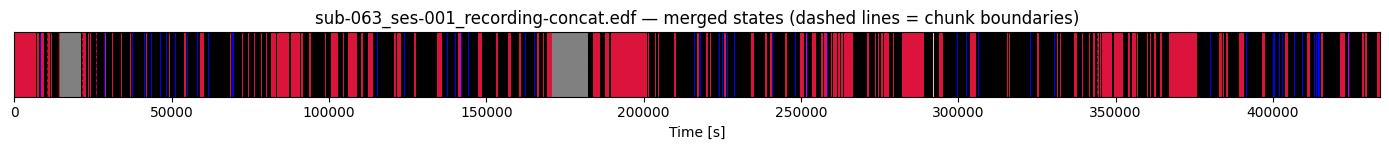

In [11]:
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba


def _hypnogram_overview(ax, label_model_vec, epoch_s, *, max_bins=3000):
    state_to_color = configuration.state_to_color
    int_to_state = configuration.int_to_state

    n_epochs = len(label_model_vec)
    n_bins = max(1, min(n_epochs, max_bins))
    edges = np.linspace(0, n_epochs, n_bins + 1).astype(int)

    colors = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        unique_values = np.unique(label_model_vec[lo:hi])
        if len(unique_values) == 1:
            state_name = int_to_state.get(int(unique_values[0]), "undefined")
            colors.append(state_to_color.get(state_name, "black"))
        else:
            colors.append("black")

    image = np.array([to_rgba(color) for color in colors])[np.newaxis, :, :]
    extent = (0, n_epochs * epoch_s, 0, 1)
    ax.imshow(image, aspect="auto", extent=extent, interpolation="nearest")
    ax.set_yticks([])
    ax.set_xlabel("Time [s]")


fig, ax = plt.subplots(figsize=(14, 1.6))
_hypnogram_overview(ax, merged_df["label_model"].to_numpy(dtype=int), configuration.time_resolution)
for chunk in prepared.scoring_chunks[1:]:
    ax.axvline(chunk.original_start_s, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_title(f"{EDF_PATH.name} \u2014 merged states (dashed lines = chunk boundaries)")
fig.tight_layout()
plt.show()


## 9. (Diagnostic) Per-Chunk Feature Normalization Statistics

Recomputes the exact robust mean/std that
`preprocess_signals.preprocess`'s `robust_normalize(..., p=5., axis=1,
method='standard score')` step derives per frequency band, per channel, per
chunk — the statistic the earlier investigation identified as the likely
root cause: a chunk's mean/std shift with its length and gap content, which
shifts every epoch's normalized feature value and can bias the LDA/HMM's
state assignment across the whole chunk. Compare `robust_mean`/`robust_std`
across chunks for the same channel/frequency band — large swings there are
the mechanism, not just a symptom.


In [12]:
from hypnose_somnotate.somnotate_pipeline.preprocessing.preprocess_signals import get_spectrogram
from hypnose_somnotate.somnotate._utils import _truncate_signals

LOW_CUT, HIGH_CUT = 1.0, 90.0
NOTCH_LOW, NOTCH_HIGH = 45.0, 55.0
ROBUST_P = 5.0  # matches preprocess_signals.preprocess's p=5.


def _robust_stats_per_frequency(raw_signal_1d, sampling_rate_hz, time_resolution_s):
    nperseg = int(round(sampling_rate_hz * time_resolution_s))
    frequencies, _, spectrogram = get_spectrogram(
        raw_signal_1d, fs=sampling_rate_hz, nperseg=nperseg, noverlap=0
    )
    mask = (frequencies >= LOW_CUT) & (frequencies < HIGH_CUT)
    frequencies, spectrogram = frequencies[mask], spectrogram[mask]
    mask = (frequencies >= NOTCH_LOW) & (frequencies <= NOTCH_HIGH)
    frequencies, spectrogram = frequencies[~mask], spectrogram[~mask]

    spectrogram = np.log(spectrogram + 1)
    means = np.array([np.mean(_truncate_signals(row.copy(), ROBUST_P, 100.0 - ROBUST_P)) for row in spectrogram])
    stds = np.array([np.std(_truncate_signals(row.copy(), ROBUST_P, 100.0 - ROBUST_P)) for row in spectrogram])
    return frequencies, means, stds


channel_names = ["EEG1", "EEG2", "EMG"]
stats_rows = []
for chunk_id, chunk in enumerate(prepared.scoring_chunks):
    for ch_idx, ch_name in enumerate(channel_names):
        frequencies, means, stds = _robust_stats_per_frequency(
            chunk.raw_signal[:, ch_idx].astype(float), SAMPLING_RATE_HZ, configuration.time_resolution
        )
        stats_rows.append(
            {
                "chunk_id": chunk_id,
                "channel": ch_name,
                "mean_of_robust_mean": float(np.mean(means)),
                "mean_of_robust_std": float(np.mean(stds)),
            }
        )

normalization_stats_df = pd.DataFrame(stats_rows)
normalization_stats_df.pivot(index="chunk_id", columns="channel", values="mean_of_robust_mean")


channel,EEG1,EEG2,EMG
chunk_id,,,
0,7.725123,8.323466,11.335258
1,7.658443,8.237322,10.152355
2,7.715886,8.321734,11.091284
3,7.678728,8.184740,9.331995
4,7.756195,8.257118,9.969322
5,7.717420,8.181217,9.135116
6,7.756032,8.255084,10.013645


In [13]:
normalization_stats_df.pivot(index="chunk_id", columns="channel", values="mean_of_robust_std")


channel,EEG1,EEG2,EMG
chunk_id,,,
0,0.545898,0.554577,1.188671
1,0.604637,0.626243,1.476465
2,0.558651,0.571905,1.367390
3,0.598562,0.626330,1.875433
4,0.603281,0.641512,1.984642
5,0.591682,0.621632,1.764961
6,0.606264,0.645537,2.035243


### 9b. Local (per-chunk) vs. Global (pooled) Normalization Baselines

Appends the `global_stats` computed in section 4b — the pooled, gap-excluded
baseline `compute_global_normalization_stats` would apply to *every* chunk
under `GLOBAL_NORMALIZATION = True` — as one extra row alongside each
chunk's own local statistics from section 9. The bigger the spread between
each chunk's row and the `global (pooled)` row, the more that chunk's
classification would change if you re-run this notebook with
`GLOBAL_NORMALIZATION = True`.


In [14]:
global_rows = []
for ch_idx, ch_name in enumerate(channel_names):
    stats = global_stats[ch_idx] if ch_idx < len(global_stats) else None
    if stats is None:
        continue
    mean, std = stats
    global_rows.append(
        {
            "chunk_id": "global (pooled)",
            "channel": ch_name,
            "mean_of_robust_mean": float(np.mean(mean)),
            "mean_of_robust_std": float(np.mean(std)),
        }
    )

local_stats_df = pd.DataFrame(stats_rows)
comparison_df = pd.concat([local_stats_df, pd.DataFrame(global_rows)], ignore_index=True)

comparison_df.pivot(index="chunk_id", columns="channel", values="mean_of_robust_mean")


The history saving thread hit an unexpected error (OperationalError('database is locked')).History will not be written to the database.


channel,EEG1,EEG2,EMG
chunk_id,,,
0,7.725123,8.323466,11.335258
1,7.658443,8.237322,10.152355
2,7.715886,8.321734,11.091284
3,7.678728,8.184740,9.331995
4,7.756195,8.257118,9.969322
5,7.717420,8.181217,9.135116
6,7.756032,8.255084,10.013645
global (pooled),7.724421,8.228484,9.748056


In [15]:
comparison_df.pivot(index="chunk_id", columns="channel", values="mean_of_robust_std")


channel,EEG1,EEG2,EMG
chunk_id,,,
0,0.545898,0.554577,1.188671
1,0.604637,0.626243,1.476465
2,0.558651,0.571905,1.367390
3,0.598562,0.626330,1.875433
4,0.603281,0.641512,1.984642
5,0.591682,0.621632,1.764961
6,0.606264,0.645537,2.035243
global (pooled),0.603764,0.637339,1.968319
